In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import catboost
except ImportError:
    %pip install catboost

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving medical_risk_dataset_1000.csv to medical_risk_dataset_1000 (1).csv


# EDA

In [ ]:


data_df = pd.read_csv("/content/medical_risk_dataset_1000.csv")
display(data_df.head())

User uploaded file "medical_risk_dataset_1000 (1).csv" with length 26434 bytes


,hemoglobin,wbc,platelets,glucose,risk_level
0,7.2,7393,331950,70,low
1,8.0,12214,129394,113,medium
2,8.5,7194,198617,90,low
3,9.9,14753,203877,174,medium
4,8.9,10439,197616,201,medium


In [ ]:
#
display(data_df.drop(columns=['risk_level']).describe())

,hemoglobin,wbc,platelets,glucose
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,11.022300,14102.557000,230405.496000,159.261000
std,2.974956,6234.482049,123889.420262,52.105084
min,6.000000,3002.000000,20034.000000,70.000000
25%,8.500000,8857.500000,125958.000000,114.750000
50%,10.800000,14098.500000,225219.500000,158.000000
75%,13.500000,19610.250000,335753.500000,206.000000
max,16.500000,24987.000000,449844.000000,250.000000


In [ ]:
display(data_df['risk_level'].value_counts())

,count
risk_level,
medium,419
low,366
high,215


/tmp/ipykernel_1720/569622794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='risk_level', data=data_df, palette='viridis', order=data_df['risk_level'].value_counts().index)


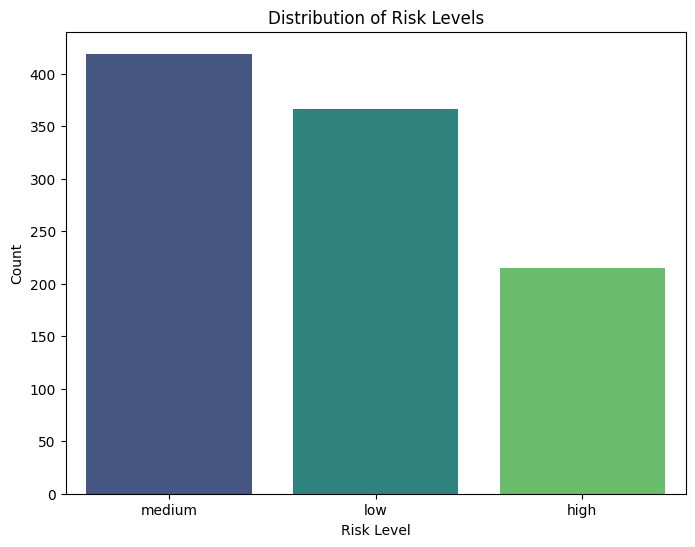

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='risk_level', data=data_df, palette='viridis', order=data_df['risk_level'].value_counts().index)
plt.title('Distribution of Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.show()

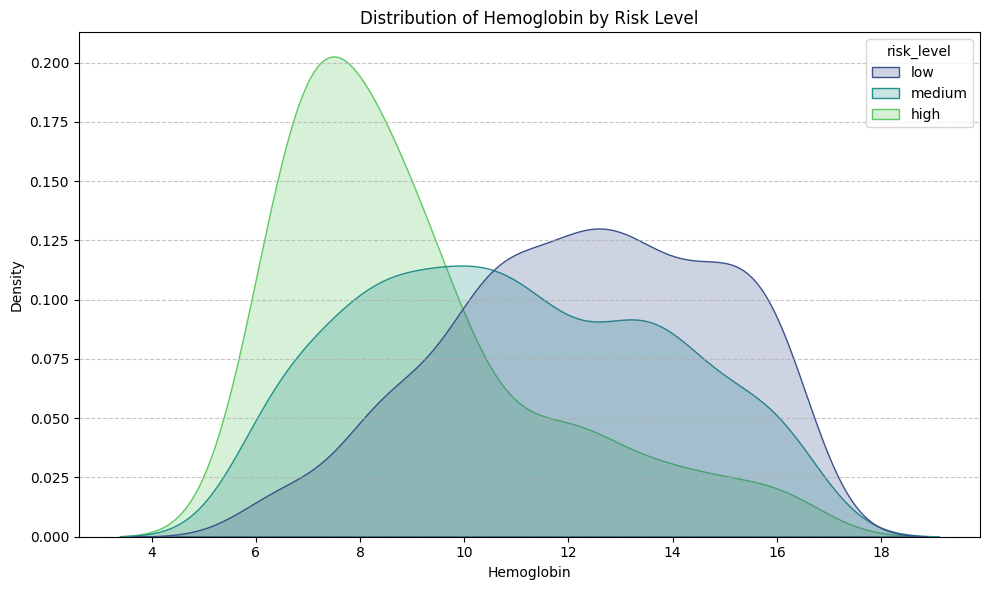

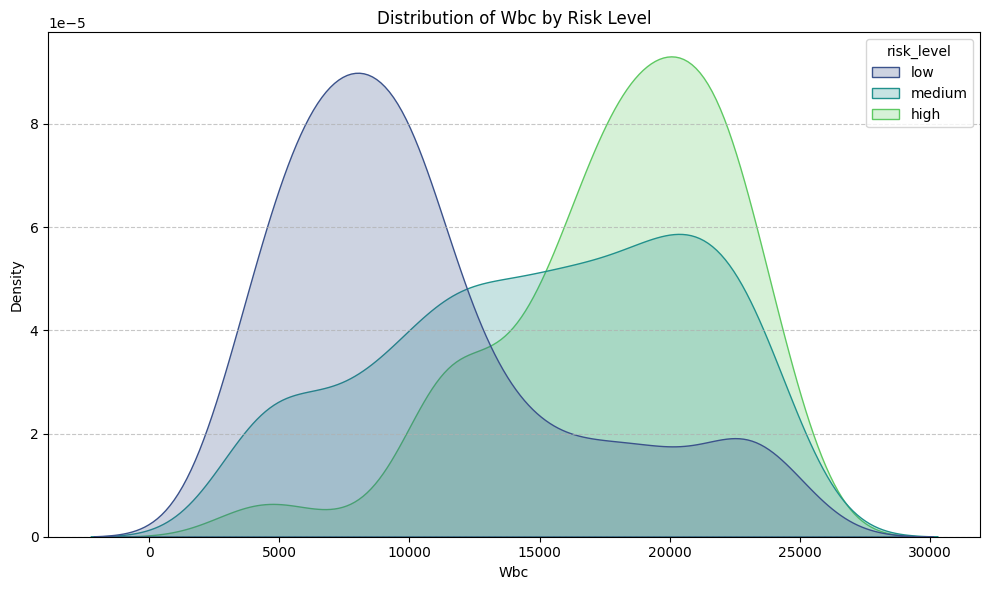

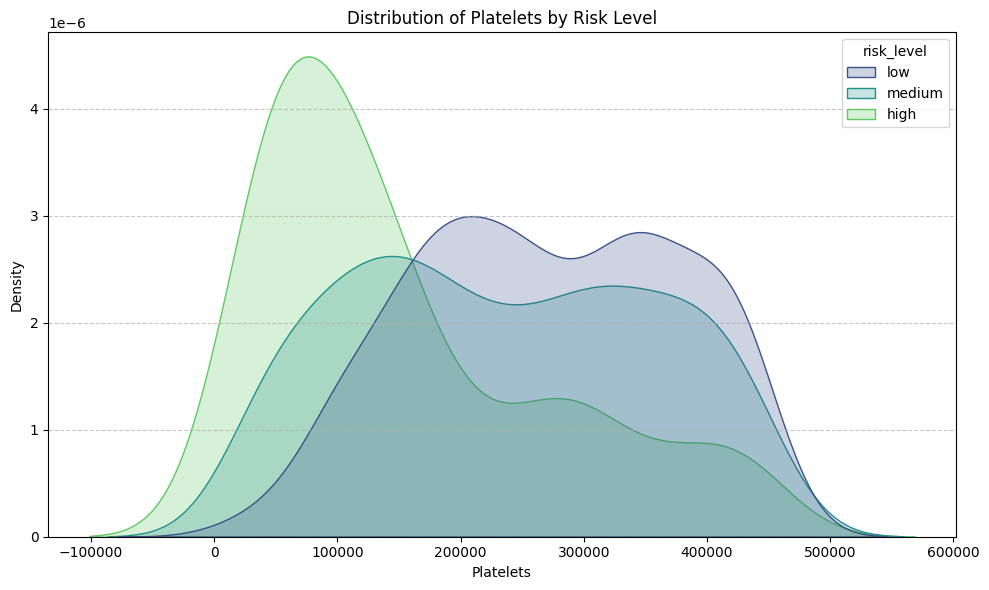

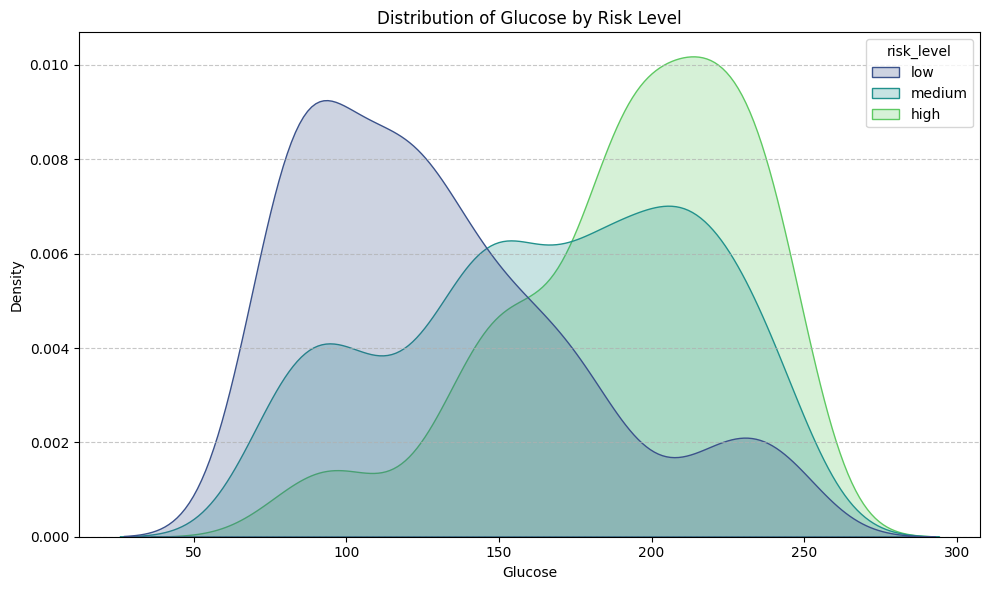

In [ ]:
continuous_features = ['hemoglobin', 'wbc', 'platelets', 'glucose']

for feature in continuous_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=data_df, x=feature, hue='risk_level', fill=True, common_norm=False, palette='viridis', hue_order=['low', 'medium', 'high'])
    plt.title(f'Distribution of {feature.replace("_", " ").title()} by Risk Level')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Density')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# null values

In [ ]:
display(data_df.isnull().sum())

,0
hemoglobin,0
wbc,0
platelets,0
glucose,0
risk_level,0


In [ ]:
from sklearn.preprocessing import StandardScaler
data_transformed_df = data_df.copy()


scaler = StandardScaler()
data_transformed_df[continuous_features] = scaler.fit_transform(data_transformed_df[continuous_features])
risk_level_mapping = {'low': 0, 'medium': 1, 'high': 2}
data_transformed_df['risk_level'] = data_transformed_df['risk_level'].map(risk_level_mapping)

# Display
print("Transformed DataFrame head:")
display(data_transformed_df.head())

Transformed DataFrame head:


,hemoglobin,wbc,platelets,glucose,risk_level
0,-1.285469,-1.076740,0.820048,-1.713953,0
1,-1.016423,-0.303073,-0.815744,-0.888285,1
2,-0.848269,-1.108675,-0.256716,-1.329921,0
3,-0.377438,0.104382,-0.214238,0.283012,1
4,-0.713746,-0.587922,-0.264800,0.801455,1


In [ ]:
print("\nInfo of transformed DataFrame:")
data_transformed_df.info()


Info of transformed DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   hemoglobin  1000 non-null   float64
 1   wbc         1000 non-null   float64
 2   platelets   1000 non-null   float64
 3   glucose     1000 non-null   float64
 4   risk_level  1000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


In [ ]:
print("\nDescriptive statistics for standardized features:")
display(data_transformed_df[continuous_features].describe())


Descriptive statistics for standardized features:


,hemoglobin,wbc,platelets,glucose
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,1.527667e-16,-1.101341e-16,-1.119105e-16,8.881784e-17
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-1.689038e+00,-1.781401e+00,-1.698908e+00,-1.713953e+00
25%,-8.482687e-01,-8.417189e-01,-8.434922e-01,-8.546819e-01
50%,-7.476118e-02,-6.510613e-04,-4.188082e-02,-2.421320e-02
75%,8.332694e-01,8.838664e-01,8.507645e-01,8.974630e-01
max,1.842192e+00,1.746719e+00,1.772131e+00,1.742333e+00


In [ ]:
from sklearn.model_selection import train_test_split

X = data_transformed_df[continuous_features]
y = data_transformed_df['risk_level']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Verify
print("\nRisk level distribution in original data:")
display(y.value_counts(normalize=True))
print("\nRisk level distribution in training data:")
display(y_train.value_counts(normalize=True))
print("\nRisk level distribution in test data:")
display(y_test.value_counts(normalize=True))

X_train shape: (800, 4)
X_test shape: (200, 4)
y_train shape: (800,)
y_test shape: (200,)

Risk level distribution in original data:


,proportion
risk_level,
1,0.419
0,0.366
2,0.215



Risk level distribution in training data:


,proportion
risk_level,
1,0.41875
0,0.36625
2,0.21500



Risk level distribution in test data:


,proportion
risk_level,
1,0.420
0,0.365
2,0.215


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

model_results = {}

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    model_results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

    print(f"--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\n")

    return y_pred

#### 1. Logistic Regression

In [ ]:
print("Training Logistic Regression...")
start_time = time.time()
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', multi_class='auto')
log_reg_model.fit(X_train, y_train)
end_time = time.time()
print(f"Logistic Regression trained in {end_time - start_time:.2f} seconds.")

log_reg_y_pred = evaluate_model(log_reg_model, X_test, y_test, 'Logistic Regression')

Training Logistic Regression...
Logistic Regression trained in 0.01 seconds.
--- Logistic Regression Performance ---
Accuracy: 0.7550
Precision: 0.7536
Recall: 0.7550
F1 Score: 0.7532




/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


#### 2. Random Forest Classifier

In [ ]:
print("Training Random Forest Classifier...")
start_time = time.time()
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
end_time = time.time()
print(f"Random Forest Classifier trained in {end_time - start_time:.2f} seconds.")

rf_y_pred = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

Training Random Forest Classifier...
Random Forest Classifier trained in 0.29 seconds.
--- Random Forest Performance ---
Accuracy: 0.9400
Precision: 0.9403
Recall: 0.9400
F1 Score: 0.9400




#### 3. XGBoost Classifier

In [ ]:
print("Training XGBoost Classifier...")
start_time = time.time()
xgb_model = XGBClassifier(objective='multi:softmax', num_class=len(y.unique()), random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
end_time = time.time()
print(f"XGBoost Classifier trained in {end_time - start_time:.2f} seconds.")

xgb_y_pred = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

Training XGBoost Classifier...
XGBoost Classifier trained in 0.13 seconds.
--- XGBoost Performance ---
Accuracy: 0.9500
Precision: 0.9515
Recall: 0.9500
F1 Score: 0.9498




/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:04:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### 4. CatBoost Classifier

In [ ]:
print("Training CatBoost Classifier...")
start_time = time.time()
cat_model = CatBoostClassifier(random_state=42, verbose=0, iterations=100)
cat_model.fit(X_train, y_train)
end_time = time.time()
print(f"CatBoost Classifier trained in {end_time - start_time:.2f} seconds.")

cat_y_pred = evaluate_model(cat_model, X_test, y_test, 'CatBoost')

Training CatBoost Classifier...
CatBoost Classifier trained in 0.30 seconds.
--- CatBoost Performance ---
Accuracy: 0.9700
Precision: 0.9711
Recall: 0.9700
F1 Score: 0.9699




# 5. LightGM

In [ ]:
import lightgbm as lgb
print("Training CatBoost Classifier...")
start_time = time.time()
lgb_model = lgb.LGBMClassifier(objective='multiclass', num_class=3, random_state=42, verbose=0)
lgb_model.fit(X_train, y_train)
end_time = time.time()
print(f"CatBoost Classifier trained in {end_time - start_time:.2f} seconds.")

lgb_y_pred = evaluate_model(lgb_model, X_test, y_test, 'LightGM')



Training CatBoost Classifier...
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
CatBoost Classifier trained in 0.17 seconds.
--- LightGM Performance

In [ ]:
import joblib


catboost_model_filename = 'catboost_model.joblib'
scaler_filename = 'standard_scaler.joblib'

#
joblib.dump(cat_model, catboost_model_filename)
print(f"CatBoost model saved as: {catboost_model_filename}")


joblib.dump(scaler, scaler_filename)
print(f"StandardScaler saved as: {scaler_filename}")
print("\nMeans of standardized features:")
display(pd.Series(scaler.mean_, index=continuous_features))

print("\nStandard deviations (scale) of standardized features:")
display(pd.Series(scaler.scale_, index=continuous_features))

CatBoost model saved as: catboost_model.joblib
StandardScaler saved as: standard_scaler.joblib

Means of standardized features:


,0
hemoglobin,11.0223
wbc,14102.5570
platelets,230405.4960
glucose,159.2610



Standard deviations (scale) of standardized features:


,0
hemoglobin,2.973468
wbc,6231.364028
platelets,123827.460058
glucose,52.079025


In [ ]:
results_df = pd.DataFrame(model_results).T
display(results_df.sort_values(by='F1 Score', ascending=False))

,Accuracy,Precision,Recall,F1 Score
CatBoost,0.970,0.971136,0.970,0.969861
XGBoost,0.950,0.951487,0.950,0.949774
Random Forest,0.940,0.940326,0.940,0.939996
LightGM,0.940,0.940793,0.940,0.939722
Logistic Regression,0.755,0.753563,0.755,0.753178
